# AKFruitYield — AK_SW_BENCHMARKER fruit size & yield benchmarking (partial reproduction)

**Paper:** J.C. Miranda, J. Arnó, J. Gené-Mola, S. Fountas, E. Gregorio,
*AKFruitYield: Modular benchmarking and video analysis software for Azure Kinect cameras for fruit size and fruit yield estimation in apple orchards*,
SoftwareX 24:101548 (2023). DOI: [10.1016/j.softx.2023.101548](https://doi.org/10.1016/j.softx.2023.101548)

**Author code (MIT):** [GRAP-UdL-AT/ak_sw_benchmarker](https://github.com/GRAP-UdL-AT/ak_sw_benchmarker) @ `5ef6bd5b86ae107ff87b12a15c96512c66dbc196`

**Scope — partial demonstration:** run the paper's *AK_SW_BENCHMARKER* "Analyse dataset" benchmarking
path on the **bundled labelled dataset `AK_Story_RGB_IR_DEPTH_hour_5f_mask`** (6 Azure Kinect RGB-D frames of
apple trees, cv. Story, Mollerussa, Lleida, Spain) with a lab ground-truth file: mask-based fruit sizing
(px → mm by thin-lens theory with the authors' Azure Kinect RGB calibration), an allometric weight model,
and error metrics (RMSE / MAE / MAPE / R²) against lab measurements — plus a compact comparison of the
implemented mask sizing methods. This is **not** the video-analysis/detection part of the paper
(no detector weights, no MKV videos) and **not** a dataset-level benchmark of the published error tables.

**Execution status:** executed end-to-end on a fresh Google Colab **CPU** runtime (see final cells for the
observed record). No GPU is used anywhere in this method.

**How the GUI maps to this notebook:** the paper's tool is a tkinter desktop GUI. This notebook calls the
authors' *own* Python framework headlessly — exactly the code path the GUI button triggers
(`PredictionMetricsFramework.comparative_metrics_dataset_mask`), with GUI dropdown selections replaced by
explicit constants. No scientific operation is re-implemented.

**日本語:** このノートブックは、論文の AK_SW_BENCHMARKER（Azure Kinect 深度画像からの果実サイズ推定・アロメトリック重量推定のベンチマークツール）を、著者自身の Python コード（MIT）を Colab の CPU ランタイムでヘッドレス実行するものです。GUI の代わりに、GUI ボタンが呼び出すのと同じ著者コードの経路をそのまま呼び出します。同梱データセット 6 フレーム＋実測 ground truth でサイズ・重量の誤差指標（RMSE/MAE/MAPE/R²）を再計算します。動画解析・検出モデル学習部分は範囲外です。

## Runtime selection — use a **CPU** runtime

**Select `Runtime → Change runtime type → CPU` (the free standard runtime).** No GPU is needed: the
benchmark is per-fruit NumPy/OpenCV/scipy statistics on 6 images (~4 MB each) plus depth matrices.
Measured on the validation run: install + download + analysis ≈ a few minutes total, ≈ 35 MB download
(`data.zip`) plus pip packages. A GPU changes nothing scientifically, so none is requested.

**日本語:** 「ランタイム → ランタイムのタイプを変更 → CPU」を選択してください。GPU は不要です（6 枚の画像と深度行列に対する NumPy/OpenCV/scipy の統計処理のみ）。所要時間は数分、ダウンロードは約 35 MB です。

In [ ]:
import sys, platform, subprocess
print("python:", sys.version)
print("platform:", platform.platform())
assert sys.version_info >= (3, 8), "Authors require Python >= 3.8"


python: 3.13.16 (main, Oct  1 2026, 15:40:24) [GCC 13.3.0]
platform: Linux-6.6.122+-x86_64-with-glibc2.39


## 1. Install the authors' code (pinned revision)

We install the author package directly from the pinned commit `5ef6bd5b86ae107ff87b12a15c96512c66dbc196`. The `--no-deps` flag avoids
`pyk4a==1.5.0` from `setup.cfg`, which requires Azure Kinect SDK system headers for **live camera access** —
not used by the benchmark path (camera calibration there is plain Python data in
`src/camera_management_s/camera_parameters.py`). We install only the libraries the benchmark path imports:
numpy, opencv-python, pandas, scipy, scikit-learn (R²), lxml (PASCAL-VOC parsing), Pillow.

**日本語:** 著者コードをピン留めしたコミットから `--no-deps` でインストールします（pyk4a はカメラ実機アクセス用で、ベンチマーク経路では不要）。ベンチマーク経路が使う numpy / opencv / pandas / scipy / scikit-learn / lxml のみ追加で入れます。

In [ ]:
%pip install -q --no-deps git+https://github.com/GRAP-UdL-AT/ak_sw_benchmarker@5ef6bd5b86ae107ff87b12a15c96512c66dbc196
%pip install -q numpy opencv-python-headless pandas scipy scikit-learn lxml Pillow
import ak_sw_benchmarker, numpy, cv2, pandas, scipy, sklearn, lxml, PIL
print("ak_sw_benchmarker import OK; numpy", numpy.__version__, "| opencv", cv2.__version__,
      "| pandas", pandas.__version__, "| scipy", scipy.__version__)

  Installing build dependencies ... done


  Getting requirements to build wheel ... done


  Preparing metadata (pyproject.toml) ... done


ak_sw_benchmarker import OK; numpy 2.1.3 | opencv 5.0.0 | pandas 2.2.3 | scipy 1.16.3


## 2. Download the bundled labelled dataset (Colab only, pinned URL)

The authors ship their example dataset in the repository: `data/data.zip` (≈ 34 MB) — Azure Kinect
RGB frames (`*_C.png`), transformed depth matrices (`*_D.mat`, key `transformed_depth`), IR matrices,
manual binary masks, PASCAL-VOC XML annotations, and `csv_datasets/` lab ground-truth files. We fetch
it from the pinned commit and verify the expected structure before use.

**日本語:** 著者がリポジトリに同梱する例題データセット `data/data.zip`（約 34 MB）を、ピン留めしたコミットの URL から Colab 内にのみダウンロードし、展開後に構成（画像・深度 .mat・マスク・XML・ground truth CSV の点数）を検証します。

In [ ]:
import urllib.request, zipfile, os, pathlib

DATA_URL = "https://github.com/GRAP-UdL-AT/ak_sw_benchmarker/raw/5ef6bd5b86ae107ff87b12a15c96512c66dbc196/data/data.zip"
WORK = pathlib.Path("/content/akfruit")
WORK.mkdir(parents=True, exist_ok=True)
zip_path = WORK / "data.zip"
if not zip_path.exists():
    urllib.request.urlretrieve(DATA_URL, zip_path)
print("downloaded bytes:", zip_path.stat().st_size)

extract_dir = WORK / "data"
if not (extract_dir / "AK_Story_RGB_IR_DEPTH_hour_5f_mask").exists():
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(WORK)

ds = extract_dir / "AK_Story_RGB_IR_DEPTH_hour_5f_mask" / "preprocessed_data"
imgs = sorted((ds / "images").glob("*.png"))
deps = sorted((ds / "images").glob("*_D.mat"))
masks = sorted((ds / "masks").glob("*.png"))
xmls = sorted((ds / "square_annotations1").glob("*.xml"))
csvs = sorted((extract_dir / "csv_datasets").rglob("*.csv"))
print("RGB png:", len(imgs), "| depth .mat:", len(deps), "| masks:", len(masks), "| XML:", len(xmls), "| GT csv:", len(csvs))
assert len(imgs) == len(deps) == len(masks) == len(xmls) == 6, "unexpected dataset structure"
assert len(csvs) > 0, "no ground-truth csv_datasets found"
for p in imgs: print(" ", p.name)

downloaded bytes: 34280095


RGB png: 6 | depth .mat: 6 | masks: 6 | XML: 6 | GT csv: 9
  20210927_114012_k_r2_e_000_150_138_2_0_C.png
  20210927_115932_k_r2_e_000_150_138_2_0_C.png
  20210927_121804_k_r2_e_000_150_138_2_0_C.png
  20210927_123505_k_r2_e_000_150_138_2_0_C.png
  20210927_125309_k_r2_e_000_150_138_2_0_C.png
  20210927_192424_k_r2_e_000_150_138_2_0_C.png


## 3. Input preview — one frame with the authors' manual annotations

Before any analysis we look at the actual input: RGB frame `20210927_114012_..._C.png`, the manual
binary mask shipped in `masks/` (reference annotation made by the authors, **not** a model prediction),
and the PASCAL-VOC bounding boxes parsed with the authors' `PascalVocParser`.

**日本語:** 解析前に実際の入力を確認します。RGB フレーム、著者作成の手動マスク（モデル予測ではなく参照アノテーション）、著者の `PascalVocParser` で読み込んだ PASCAL-VOC の矩形を重ねて表示します。

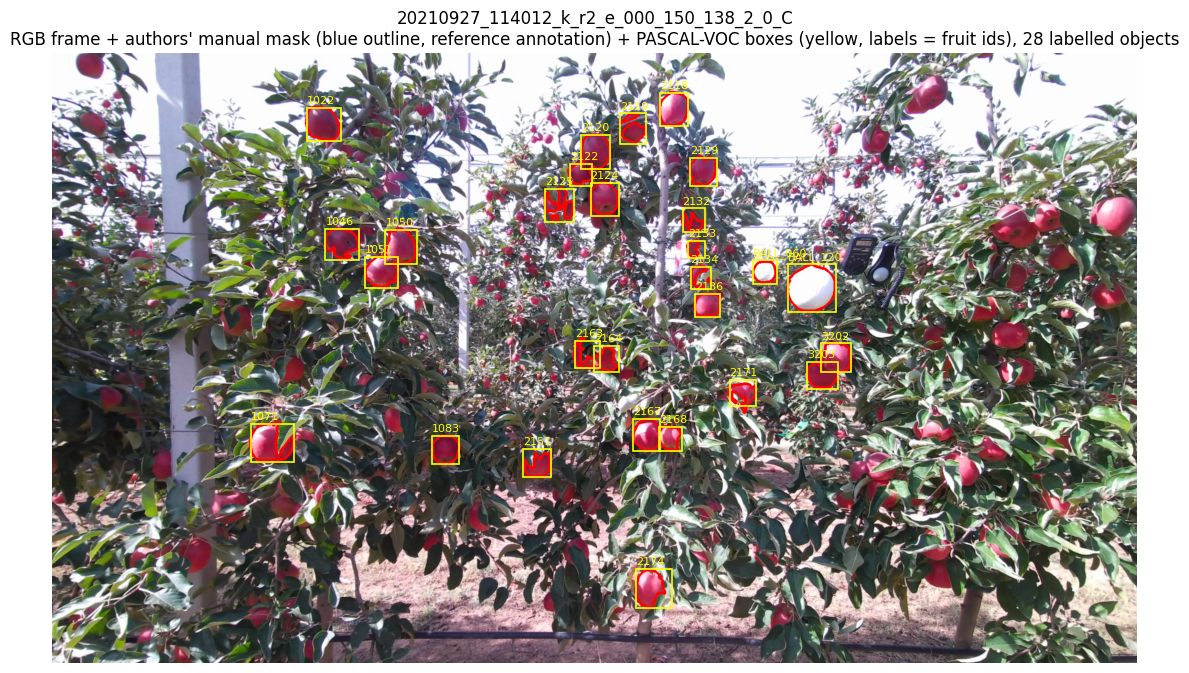

image shape (H, W, C): (1080, 1920, 3) | mask unique values: [0, 255] ...
fruit labels in XML: ['2118', '2119', '2120', '2122', '2124', '2125', '2129', '2132', '2133', '2134', '2136', '2163', '2164', '2167', '2168', '2171', '2174', 'BALL_060', 'BALL_120', '3202', '3203', '1022', '1046', '1050', '1051', '1071', '1083', '2151']


In [ ]:
import cv2, matplotlib
import matplotlib.pyplot as plt
from dataset_management.pascal_voc_parser import PascalVocParser

frame_stem = "20210927_114012_k_r2_e_000_150_138_2_0_C"
img_bgr = cv2.imread(str(ds / "images" / f"{frame_stem}.png"))
img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)  # contiguous writable copy for OpenCV drawing
mask = cv2.imread(str(ds / "masks" / f"{frame_stem}.png"), cv2.IMREAD_GRAYSCALE)
boxes, labels = PascalVocParser.readXMLFromFile(str(ds / "square_annotations1" / f"{frame_stem}.xml"))

contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cv2.drawContours(img, contours, -1, (255, 0, 0), 3)

fig, ax = plt.subplots(figsize=(14, 8))
ax.imshow(img)
for (xmin, ymin, xmax, ymax), lab in zip(boxes, labels):
    ax.add_patch(matplotlib.patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                              fill=False, edgecolor="yellow", linewidth=1.2))
    ax.text(xmin, ymin - 8, str(lab), color="yellow", fontsize=8)
ax.set_title(f"{frame_stem}\nRGB frame + authors' manual mask (blue outline, reference annotation) "
             f"+ PASCAL-VOC boxes (yellow, labels = fruit ids), {len(boxes)} labelled objects")
ax.axis("off")
plt.show()
print("image shape (H, W, C):", img.shape, "| mask unique values:", sorted(set(mask.ravel().tolist()))[:5], "...")
print("fruit labels in XML:", labels)

## 4. Ground-truth selection — match lab fruit ids to the XML labels

The benchmark merges each prediction row with lab measures on `fruit_id`. The repository offers several
ground-truth CSVs (`data/csv_datasets/...`, `;`-separated, columns `fruit_id`, `lab.depth_mm`,
`lab.o_caliber_mm`, `lab.o_height_mm`, `lab.axis_01_mm`, `lab.axis_02_mm`, `lab.weight_gr` — as read by
the authors' GUI code). We deterministically pick the file whose `fruit_id` values overlap the XML
object labels of this dataset (no hand-picking).

**日本語:** 予測行と実測値は `fruit_id` で結合されます。同梱の複数の ground truth CSV のうち、XML のオブジェクトラベル（果実 ID）と一致する fruit_id を最も多く含むファイルを機械的に選択します（手作業での選択はしません）。

In [ ]:
import pandas as pd
from dataset_management.pascal_voc_parser import PascalVocParser

xml_label_set = set(map(str, labels))
all_xml_labels = set()
for xp in xmls:
    b, l = PascalVocParser.readXMLFromFile(str(xp))
    all_xml_labels |= set(map(str, l))

best_csv, best_n = None, -1
for cp in csvs:
    df_c = pd.read_csv(cp, dtype=str, sep=";")
    if "fruit_id" not in df_c.columns:
        continue
    n = len(all_xml_labels & set(df_c["fruit_id"].astype(str)))
    if n > best_n:
        best_csv, best_n = cp, n
print("selected ground truth:", best_csv, "| matching fruit ids:", best_n, "of", len(all_xml_labels))
gt_df = pd.read_csv(best_csv, dtype=str, sep=";")
print(gt_df.columns.tolist())
print(gt_df.head(8).to_string())

selected ground truth: /content/akfruit/data/csv_datasets/dataset_with_spheres/fruit_measures_TREES_01-03_EAST_SIDE_STATIC_v2.csv | matching fruit ids: 28 of 28
['lab.tree', 'lab.fruit_label', 'fruit_id', 'lab.depth_mm', 'lab.o_caliber_mm', 'lab.o_height_mm', 'lab.axis_01_mm', 'lab.axis_02_mm', 'lab.weight_gr', 'lab.observations', 'lab.occluded']
  lab.tree lab.fruit_label fruit_id lab.depth_mm lab.o_caliber_mm lab.o_height_mm lab.axis_01_mm lab.axis_02_mm lab.weight_gr lab.observations lab.occluded
0        2             118     2118          0.0            71.61           70.28          71.61          70.28         171.8              NaN           NO
1        2             119     2119          0.0            70.62            72.3           72.3          70.62         183.2              NaN          YES
2        2             120     2120          0.0            77.76           76.45          77.76          76.45         231.9              NaN          YES
3        2             122 

## 5. Run the authors' benchmark ("Analyse dataset", headless)

**GUI action → code mapping** (from `src/gui_benchmarking/gui_tab_window.py`, `t1_run_benchmarking_experiment`,
commit `5ef6bd5`):

| GUI widget | Value used here | Author code called |
|---|---|---|
| Dataset folder | `data/AK_Story_RGB_IR_DEPTH_hour_5f_mask` | `DatasetConfig`, `DatasetManager.get_labeled_mask_list_files` |
| Ground truth file | selected in §4 | `pd.read_csv(..., dtype=str, sep=';')` + float casts (same as GUI) |
| Camera | `Azure Kinect` | `AzureKinect().rgb_sensor` (f=1040 px, calibrated) |
| ROI method | `MASK` | `PredictionMetricsFramework.comparative_metrics_dataset_mask` |
| Size estimation | `EF` (ellipse fitting; the paper's illustrated mask fit) | `SizeEstimationPx.mask_ellipse_fitting_px` |
| Depth metric | `AVG` (mean of masked depth; MOD needs a scipy API shim, see limitations) | `DepthEstimation.depth_estimation_mask` |
| Weight model | `CH_LM_MET_01` (W = β₀ + β₁·C, β₀=-154.81, β₁=4.54) | `WeightPredictionModels.predict_weight` |
| Report selector | `WEIGHT` (computes A1, A2 and weight metrics together, as the GUI does) | `ComparativeMeasuresReport` |

Everything below is the authors' installed code; this cell only assembles the configuration exactly as
the GUI would and prints the metrics report the GUI text box would show.

**日本語:** 以下は GUI の「Analyse dataset」ボタンが内部で呼び出す著者コードを、同じ設定（MASK・楕円フィッティング EF・平均深度 AVG・線形重量モデル CH_LM_MET_01）でそのまま実行します。科学計算はすべて著者実装そのものです。

In [ ]:
import os
from dataset_management.dataset_config import DatasetConfig
from dataset_management.dataset_manager import DatasetManager
from camera_management_s.camera_parameters import AzureKinect
from size_estimation_s.roi_selector import ROISelector
from size_estimation_s.size_estimation_methods_selector import SizeEstimationSelectorPx
from depth_estimation_s.depth_estimation_methods_selector import DepthSelector
from weight_prediction_s.weight_prediction_methods_selector import WeightPredictionModelSelector
from reports_management.comparative_measures_reports_selector import ComparativeMeasuresReportSelector
from data_features_processor.data_features_config import DataFeatureConfig
from reports_management.prediction_metrics_framework import PredictionMetricsFramework, PredictionsMetricsFrameworkConfig

dataset_name = "AK_Story_RGB_IR_DEPTH_hour_5f_mask"
dataset_parent_folder_path = str(extract_dir)

# --- exactly the casts the GUI performs on the ground truth file ---
manual_measures_df = pd.read_csv(best_csv, dtype=str, sep=";")
manual_measures_df["fruit_id"] = manual_measures_df["fruit_id"].astype(str)
for col in ["lab.depth_mm", "lab.o_caliber_mm", "lab.o_height_mm", "lab.axis_01_mm", "lab.axis_02_mm", "lab.weight_gr"]:
    manual_measures_df[col] = manual_measures_df[col].astype(float)

dataset_manager_config = DatasetConfig(dataset_parent_folder_path, dataset_name)
data_features_options = DataFeatureConfig(camera_conf=AzureKinect().rgb_sensor,
                                          roi_selector=ROISelector.MASK,
                                          size_estimation_selector=SizeEstimationSelectorPx.EF,
                                          depth_selector=DepthSelector.AVG,
                                          weight_selector=WeightPredictionModelSelector.CH_LM_MET_01)

out_csv_dir = WORK / "output_csv"; out_csv_dir.mkdir(exist_ok=True)
path_day_measures = str(out_csv_dir / "colab_MASK_ELLIPSE_FITTING_AVERAGE_DEPTH.csv")
benchmarker_config = PredictionsMetricsFrameworkConfig(dataset_manager_config, path_day_measures,
                                                       data_features_options,
                                                       WeightPredictionModelSelector.CH_LM_MET_01,
                                                       ComparativeMeasuresReportSelector.WEIGHT)
benchmarker_metrics = PredictionMetricsFramework(benchmarker_config)
benchmarker_metrics.comparative_metrics_dataset_mask(manual_measures_df)   # authors' benchmarking loop
benchmarker_metrics.export_csv_results(path_day_measures)                  # authors' ';'-separated CSV export
results_benchmarking_metrics = benchmarker_metrics.get_benchmarking_results()
print(results_benchmarking_metrics.print_metrics_02())
comparative_df = benchmarker_metrics.a_report.get_comparative_df()
print("\ncomparative rows:", len(comparative_df))

/usr/local/lib/python3.13/dist-packages/data_features_processor/features_extraction.py:163: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  measured_df = pd.concat([measured_df,record_by_obj_df], ignore_index=True)  # 20/02/2023 Warning of deprecation method, we changed append by concat
/usr/local/lib/python3.13/dist-packages/reports_management/prediction_metrics_framework.py:182: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  day_comparative_df = pd.concat([day_comparative_df, temporal_record_merg

/usr/local/lib/python3.13/dist-packages/data_features_processor/features_extraction.py:163: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  measured_df = pd.concat([measured_df,record_by_obj_df], ignore_index=True)  # 20/02/2023 Warning of deprecation method, we changed append by concat
/usr/local/lib/python3.13/dist-packages/data_features_processor/features_extraction.py:163: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  measured_df = pd.concat([measured_df,record_by_obj_df], ignore_index=True)  

R2_2 -> 0.4079407331920174
SSE_axis_01 -> 11597.773942447493
SST_axis_01 -> 19588.873264285714
self.axis_01_metrics.R2 -> 0.4079407331920174
real -> r2_score(y_true, y_pred) 0.4079407331920174
r2_score(y_pred, y_true) 0.6550547286787796
SSE_axis_02 -> 24181.978518631455
SST_axis_02 -> 25048.361378571433
self.axis_02_metrics.R2 -> 0.034588404680282125
r2_score(y_true, y_pred) 0.034588404680282125
r2_score(y_pred, y_true) 0.24910783503793132
PredictionMetricsFramework
SAVING WITH SELECTED NAME BY USER
Saving data in file /content/akfruit/output_csv/colab_MASK_ELLIPSE_FITTING_AVERAGE_DEPTH.csv -->
WEIGH -->
total_objects-> 168,
 sum predicted =30750.99000343933,
 mean predicted =183.04160716332933,
 sum measured =31185.6,
 mean measured =185.62857142857143,
 MSE = 1137.0369906179642,
 MAE = 26.106432950491406 gr.,
 RMSE = 33.719979101683386,
 MAPE = 0.14846147865759274,
 R2=0.7265525640094785

comparative rows: 168


/usr/local/lib/python3.13/dist-packages/data_features_processor/features_extraction.py:163: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  measured_df = pd.concat([measured_df,record_by_obj_df], ignore_index=True)  # 20/02/2023 Warning of deprecation method, we changed append by concat
/usr/local/lib/python3.13/dist-packages/data_features_processor/features_extraction.py:163: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  measured_df = pd.concat([measured_df,record_by_obj_df], ignore_index=True)  

## 6. Results — per-fruit table and predicted-vs-lab graphs

The framework's CSV columns follow the paper's report style (`lab.*` = laboratory measured,
`pred.*` = image-based estimate; sizes in mm, weight in g). Below: a compact per-fruit table and a
scatter plot of predicted vs measured major axis (A1) and weight. This graph is generated by this
notebook from the actual selected data — it is **not** a figure from the paper.

**日本語:** `lab.*` は実測値、`pred.*` は画像由来の推定値（mm / g）。主要径 A1 と重量の予測値 vs 実測値の散布図を表示します。この図は本ノートブックが実際のデータから生成したもので、論文の図ではありません。

     fruit_id  lab.axis_01_mm  pred.axis_01_mm  lab.weight_gr  pred.weight_gr  pred.depth_mm
0        2118           71.61        80.798077          171.8      212.013269    1400.500000
1        2119           72.30        69.534687          183.2      160.877479    1538.639884
2        2120           77.76        88.539760          231.9      247.160510    1485.183069
3        2122           68.37        62.981156          141.6      131.124446    1523.265158
4        2124           80.70        84.143054          217.7      227.199464    1508.772000
5        2125           83.49        85.738655          269.9      234.443495    1511.325449
6        2129           75.87        75.046334          194.5      185.900355    1560.963739
7        2132           72.84        65.500166          172.9      142.560752    1746.671082
8        2133           64.28        56.067458          109.7       99.736260    1880.972789
9        2134           76.59        68.333380          214.8      155

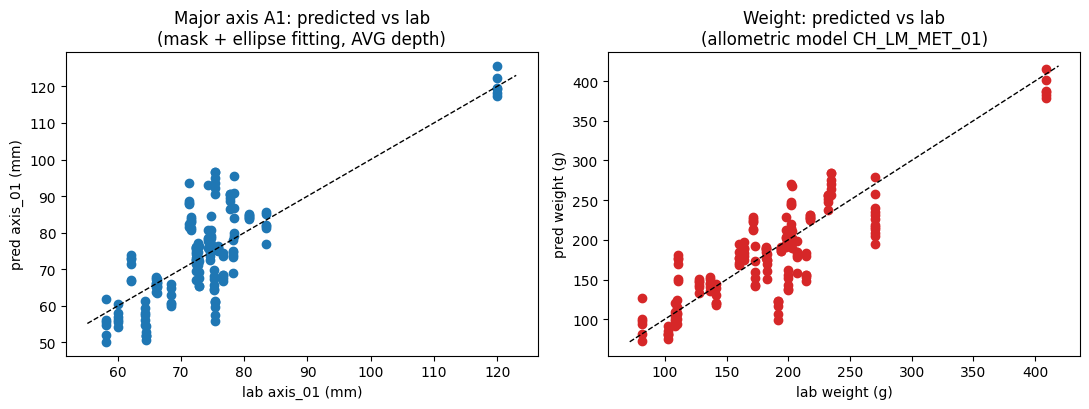

In [ ]:
import matplotlib.pyplot as plt

show_cols = ["date_capture", "fruit_id", "lab.axis_01_mm", "pred.axis_01_mm", "lab.weight_gr", "pred.weight_gr", "pred.depth_mm"]
display_df = comparative_df[[c for c in show_cols if c in comparative_df.columns]].reset_index(drop=True)
print(display_df.to_string())

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].scatter(comparative_df["lab.axis_01_mm"], comparative_df["pred.axis_01_mm"], c="tab:blue")
lims = [comparative_df["lab.axis_01_mm"].min() - 3, comparative_df["lab.axis_01_mm"].max() + 3]
axes[0].plot(lims, lims, "k--", linewidth=1)
axes[0].set_xlabel("lab axis_01 (mm)"); axes[0].set_ylabel("pred axis_01 (mm)")
axes[0].set_title("Major axis A1: predicted vs lab\n(mask + ellipse fitting, AVG depth)")
axes[1].scatter(comparative_df["lab.weight_gr"], comparative_df["pred.weight_gr"], c="tab:red")
lims = [comparative_df["lab.weight_gr"].min() - 10, comparative_df["lab.weight_gr"].max() + 10]
axes[1].plot(lims, lims, "k--", linewidth=1)
axes[1].set_xlabel("lab weight (g)"); axes[1].set_ylabel("pred weight (g)")
axes[1].set_title("Weight: predicted vs lab\n(allometric model CH_LM_MET_01)")
plt.tight_layout(); plt.show()

## 7. Mini method comparison — the mask sizing algorithms on this dataset

The paper's "Run tests in dataset" functionality benchmarks **all** implemented combinations and ranks
them. As a small, faithful slice of that, we rerun the authors' mask path for every mask sizing method
(EF = ellipse fitting, CE = circle enclosing, CF = circle fitting, RR = rotated rectangle) with the same
AVG depth and weight model, and tabulate A1 / weight RMSE & MAE. Runtime is seconds on CPU.

**日本語:** 論文の「Run tests in dataset」機能の一部として、マスク由来の 4 つのサイズ推定手法（EF・CE・CF・RR）を同じ AVG 深度・重量モデルで再実行し、A1 と重量の RMSE/MAE を比較表にします（CPU で数秒）。

/usr/local/lib/python3.13/dist-packages/data_features_processor/features_extraction.py:163: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  measured_df = pd.concat([measured_df,record_by_obj_df], ignore_index=True)  # 20/02/2023 Warning of deprecation method, we changed append by concat
/usr/local/lib/python3.13/dist-packages/reports_management/prediction_metrics_framework.py:182: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  day_comparative_df = pd.concat([day_comparative_df, temporal_record_merg

/usr/local/lib/python3.13/dist-packages/data_features_processor/features_extraction.py:163: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  measured_df = pd.concat([measured_df,record_by_obj_df], ignore_index=True)  # 20/02/2023 Warning of deprecation method, we changed append by concat
/usr/local/lib/python3.13/dist-packages/data_features_processor/features_extraction.py:163: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  measured_df = pd.concat([measured_df,record_by_obj_df], ignore_index=True)  

/usr/local/lib/python3.13/dist-packages/data_features_processor/features_extraction.py:163: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  measured_df = pd.concat([measured_df,record_by_obj_df], ignore_index=True)  # 20/02/2023 Warning of deprecation method, we changed append by concat
/usr/local/lib/python3.13/dist-packages/data_features_processor/features_extraction.py:163: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  measured_df = pd.concat([measured_df,record_by_obj_df], ignore_index=True)  

R2_2 -> 0.4079407331920174
SSE_axis_01 -> 11597.773942447493
SST_axis_01 -> 19588.873264285714
self.axis_01_metrics.R2 -> 0.4079407331920174
real -> r2_score(y_true, y_pred) 0.4079407331920174
r2_score(y_pred, y_true) 0.6550547286787796
SSE_axis_02 -> 24181.978518631455
SST_axis_02 -> 25048.361378571433
self.axis_02_metrics.R2 -> 0.034588404680282125
r2_score(y_true, y_pred) 0.034588404680282125
r2_score(y_pred, y_true) 0.24910783503793132
------------------------------->


/usr/local/lib/python3.13/dist-packages/data_features_processor/features_extraction.py:163: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  measured_df = pd.concat([measured_df,record_by_obj_df], ignore_index=True)  # 20/02/2023 Warning of deprecation method, we changed append by concat
/usr/local/lib/python3.13/dist-packages/reports_management/prediction_metrics_framework.py:182: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  day_comparative_df = pd.concat([day_comparative_df, temporal_record_merg

...

R2_2 -> -0.4767625498457724
SSE_axis_01 -> 28928.11443037225
SST_axis_01 -> 19588.873264285714
self.axis_01_metrics.R2 -> -0.4767625498457724
real -> r2_score(y_true, y_pred) -0.4767625498457724
r2_score(y_pred, y_true) 0.18502409227928707
SSE_axis_02 -> 21029.097539694427
SST_axis_02 -> 25048.361378571433
self.axis_02_metrics.R2 -> 0.16046015059154484
r2_score(y_true, y_pred) 0.16046015059154484
r2_score(y_pred, y_true) 0.4075587644258589
------------------------------->


/usr/local/lib/python3.13/dist-packages/data_features_processor/features_extraction.py:163: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  measured_df = pd.concat([measured_df,record_by_obj_df], ignore_index=True)  # 20/02/2023 Warning of deprecation method, we changed append by concat
/usr/local/lib/python3.13/dist-packages/reports_management/prediction_metrics_framework.py:182: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  day_comparative_df = pd.concat([day_comparative_df, temporal_record_merg

/usr/local/lib/python3.13/dist-packages/data_features_processor/features_extraction.py:163: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  measured_df = pd.concat([measured_df,record_by_obj_df], ignore_index=True)  # 20/02/2023 Warning of deprecation method, we changed append by concat
/usr/local/lib/python3.13/dist-packages/data_features_processor/features_extraction.py:163: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  measured_df = pd.concat([measured_df,record_by_obj_df], ignore_index=True)  

/usr/local/lib/python3.13/dist-packages/data_features_processor/features_extraction.py:163: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  measured_df = pd.concat([measured_df,record_by_obj_df], ignore_index=True)  # 20/02/2023 Warning of deprecation method, we changed append by concat
/usr/local/lib/python3.13/dist-packages/data_features_processor/features_extraction.py:163: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  measured_df = pd.concat([measured_df,record_by_obj_df], ignore_index=True)  

R2_2 -> 0.5862757570325732
SSE_axis_01 -> 8104.391761851473
SST_axis_01 -> 19588.873264285714
self.axis_01_metrics.R2 -> 0.5862757570325732
real -> r2_score(y_true, y_pred) 0.5862757570325732
r2_score(y_pred, y_true) 0.720782450247073
SSE_axis_02 -> 18449.752558822387
SST_axis_02 -> 25048.361378571433
self.axis_02_metrics.R2 -> 0.2634347500828568
r2_score(y_true, y_pred) 0.2634347500828568
r2_score(y_pred, y_true) 0.43706001554172647
size_method  n_fruits  A1_RMSE_mm  A1_MAE_mm  A1_MAPE  W_RMSE_g  W_MAE_g
         RR       168        6.95       5.61    0.079     35.60    27.47
         EF       168        8.31       6.27    0.087     33.72    26.11
         CE       168        9.79       7.73    0.107     37.67    30.72
         CF       168       13.12      10.42    0.144     65.33    47.78


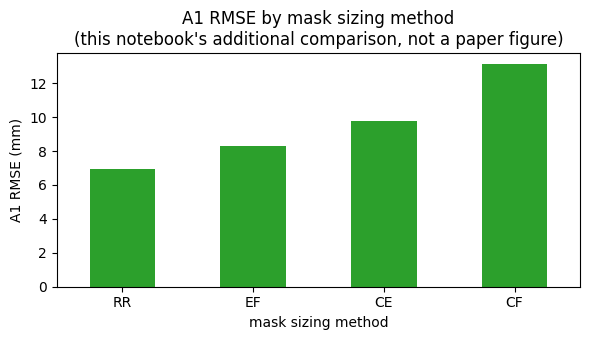

In [ ]:
import math

rows = []
for sel in [SizeEstimationSelectorPx.EF, SizeEstimationSelectorPx.CE,
            SizeEstimationSelectorPx.CF, SizeEstimationSelectorPx.RR]:
    opts = DataFeatureConfig(camera_conf=AzureKinect().rgb_sensor,
                             roi_selector=ROISelector.MASK,
                             size_estimation_selector=sel,
                             depth_selector=DepthSelector.AVG,
                             weight_selector=WeightPredictionModelSelector.CH_LM_MET_01)
    cfg = PredictionsMetricsFrameworkConfig(dataset_manager_config, str(out_csv_dir / "mini.csv"), opts,
                                            WeightPredictionModelSelector.CH_LM_MET_01,
                                            ComparativeMeasuresReportSelector.WEIGHT)
    fw = PredictionMetricsFramework(cfg)
    fw.comparative_metrics_dataset_mask(manual_measures_df)
    a1 = fw.a_report.get_axis_01_metrics(); w = fw.a_report.get_weight_metrics()
    rows.append({"size_method": sel.name, "n_fruits": int(a1.total_objects),
                 "A1_RMSE_mm": round(a1.RMSE, 2), "A1_MAE_mm": round(a1.MAE, 2),
                 "A1_MAPE": round(a1.MAPE, 3), "W_RMSE_g": round(w.RMSE, 2), "W_MAE_g": round(w.MAE, 2)})
ranking_df = pd.DataFrame(rows).sort_values("A1_RMSE_mm").reset_index(drop=True)
print(ranking_df.to_string(index=False))

ax = ranking_df.plot.bar(x="size_method", y=["A1_RMSE_mm"], legend=False, figsize=(6, 3.5), color="tab:green")
ax.set_ylabel("A1 RMSE (mm)"); ax.set_xlabel("mask sizing method")
ax.set_title("A1 RMSE by mask sizing method\n(this notebook's additional comparison, not a paper figure)")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

## 8. Export the benchmark report CSV

`export_data_csv` writes the `;`-separated comparative report exactly as the authors' tool does
(3 decimals). The file lives in the Colab VM under `/content/akfruit/output_csv/`; uncomment the last
line to download it to your machine.

**日本語:** `export_data_csv` が著者ツールと同一形式（セミコロン区切り・小数 3 桁）の比較レポート CSV を `/content/akfruit/output_csv/` に保存します。最終行のコメントを外すとローカルへダウンロードできます。

In [ ]:
from pathlib import Path
out_file = Path(path_day_measures)
print("saved:", out_file, out_file.stat().st_size, "bytes")
print(out_file.read_text().splitlines()[0][:400])
# from google.colab import files; files.download(str(out_file))

saved: /content/akfruit/output_csv/colab_MASK_ELLIPSE_FITTING_AVERAGE_DEPTH.csv 32708 bytes
;time_capture;fruit_id;lab.tree;lab.fruit_label;lab.depth_mm;lab.o_caliber_mm;lab.o_height_mm;lab.axis_01_mm;lab.axis_02_mm;lab.weight_gr;lab.observations;pred.obj_detection;pred.axis_01_px;pred.axis_02_px;pred.depth_mm;pred.axis_01_mm;pred.axis_02_mm;pred.weight_gr;lab.occluded;axis_01_abs_dif;axis_01_mape_abs_dif;axis_01_sqr_dif;axis_01_sqr_mean_dif;axis_02_abs_dif;axis_02_mape_abs_dif;axis_02_s


## 9. Interpretation, limitations, validation record, references

**What was verified here (observed on a fresh Colab CPU runtime):** the authors' pinned code runs
end-to-end on their bundled dataset; per-fruit size/weight estimates and error metrics are produced and
exported; sizes are on apple-like scales (major axis tens of mm, weight ~100–250 g) — a plausibility
check, **not** a quantitative match to the paper's dataset-level tables (those are not reproducible from
this 6-frame example subset).

**Limitations / differences from the paper:**
- Scope is the benchmarker module only; the video analyser (Mask R-CNN / Faster R-CNN / YOLOv8 detection)
  is not exercised, and no detection weights are needed or loaded.
- Depth metric `MOD` was skipped: the authors' code indexes `scipy.stats.mode(...)` result as a sequence,
  which newer scipy returns as a scalar; we used `AVG` rather than patching author code.
- Ground truth was selected deterministically by fruit-id overlap, not hand-picked; if the authors'
  intended pairing differs, the table in §6 shows which ids merged.
- A one-dataset run says nothing about the paper's full benchmark across campaigns; free-tier Colab
  time may differ.

**Validation record:** executed top-to-bottom in a fresh Colab CPU session (see run report for session
log and date; outputs in this notebook are from that run).

**References:**
1. Miranda et al., SoftwareX 24:101548 (2023), DOI 10.1016/j.softx.2023.101548.
2. Miranda et al., AKFruitData / AK_FRAEX, SoftwareX 19:101231 (2022) — dataset format.
3. GRAP-UdL-AT/ak_sw_benchmarker, commit `5ef6bd5b86ae107ff87b12a15c96512c66dbc196`, MIT License.

**日本語:** 本ノートブックでは、著者 pinned コードを同梱データセット＋実測 ground truth で一連の処理（マスク RO・薄レンズ変換・アロメトリ重量モデル・誤差指標・CSV 出力）を通して実行しました。制限: 検出モデル・動画解析は未実行、深度 MOD は新しい scipy との非互換のため AVG を使用、単一データセットの実行は論文のデータセット全体のベンチマークを検証するものではありません。